In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.datasets import fetch_covtype

In [3]:
df=pd.read_csv('/content/glass.csv')
df.head()

,RI,Na,Mg,Al,Si,K,Ca,Ba,Fe,Type
0,1.52101,13.64,4.49,1.10,71.78,0.06,8.75,0.0,0.0,1
1,1.51761,13.89,3.60,1.36,72.73,0.48,7.83,0.0,0.0,1
2,1.51618,13.53,3.55,1.54,72.99,0.39,7.78,0.0,0.0,1
3,1.51766,13.21,3.69,1.29,72.61,0.57,8.22,0.0,0.0,1
4,1.51742,13.27,3.62,1.24,73.08,0.55,8.07,0.0,0.0,1


In [5]:
X = df.drop("Type", axis=1).values
Y = df["Type"].values
print("Dataset Shape:", X.shape)
print("Target Shape:", Y.shape)

Dataset Shape: (214, 9)
Target Shape: (214,)


In [6]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [7]:
X_train, X_test, Y_train, Y_test = train_test_split(X_scaled, Y, test_size=0.2, random_state=42)

In [8]:
model_before_lda = LogisticRegression(max_iter=500)
model_before_lda.fit(X_train, Y_train)
Y_pred_before_lda = model_before_lda.predict(X_test)
accuracy_before_lda = accuracy_score(Y_test, Y_pred_before_lda)
print("Accuracy before LDA:", round(accuracy_before_lda, 3))

Accuracy before LDA: 0.721


In [9]:
lda = LDA(n_components=5)
X_lda = lda.fit_transform(X_scaled, Y)

In [10]:
expVar = lda.explained_variance_ratio_
explained_variance_df = pd.DataFrame({
    "LDA Component": [f"LD{i+1}" for i in range(len(expVar))],
    "Explained Variance": expVar
})
explained_variance_df

,LDA Component,Explained Variance
0,LD1,0.814526
1,LD2,0.116871
2,LD3,0.041256
3,LD4,0.016254
4,LD5,0.011092


In [11]:
X_train_lda, X_test_lda, Y_train_lda, Y_test_lda = train_test_split(X_lda, Y, test_size=0.2, random_state=42)

In [12]:
model_after_lda = LogisticRegression(max_iter=500)
model_after_lda.fit(X_train_lda, Y_train_lda)
Y_pred_after_lda = model_after_lda.predict(X_test_lda)
accuracy_after_lda = accuracy_score(Y_test_lda, Y_pred_after_lda)
print("Accuracy after LDA:", round(accuracy_after_lda, 3))

Accuracy after LDA: 0.721


In [13]:
comparision_df = pd.DataFrame({
    "Model": [
        "Logistic Regression (Before LDA)",
        "Logistic Regression (After LDA)"
    ],
    "Accuracy": [
        round(accuracy_before_lda, 3),
        round(accuracy_after_lda, 3)
    ]
})
comparision_df

,Model,Accuracy
0,Logistic Regression (Before LDA),0.721
1,Logistic Regression (After LDA),0.721


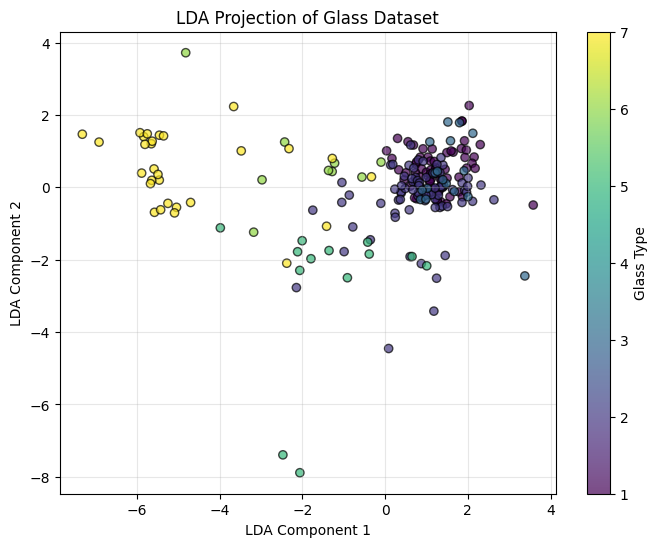

In [14]:
plt.figure(figsize=(8,6))
plt.scatter(
    X_lda[:,0],
    X_lda[:,1],
    c=Y,
    cmap='viridis',
    edgecolors='k',
    alpha=0.7
)
plt.xlabel("LDA Component 1")
plt.ylabel("LDA Component 2")
plt.title("LDA Projection of Glass Dataset")
plt.colorbar(label="Glass Type")
plt.grid(alpha=0.3)
plt.show()

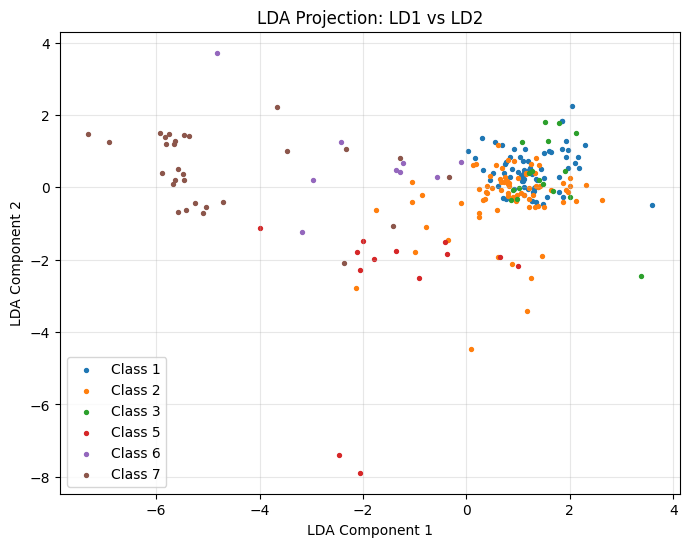

In [15]:
classes=np.unique(Y)

def plot_lda_pair(X_lda, Y, component1, component2):
    plt.figure(figsize=(8, 6))

    for cls in classes:
      plt.scatter(
          X_lda[Y==cls, component1],
          X_lda[Y==cls, component2],
          s=8,
          label=f"Class {cls}"
      )
    plt.xlabel(f"LDA Component {component1+1}")
    plt.ylabel(f"LDA Component {component2+1}")
    plt.title(f"LDA Projection: LD{component1+1} vs LD{component2+1}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.show()

plot_lda_pair(X_lda, Y, 0, 1)